In [22]:
import pandas as pd
import numpy as np

In [23]:
file_path = "/content/Retail-dataset.xlsx"

dfs = pd.read_excel(file_path, sheet_name=None)

# Unpack
orders = dfs['orders']
items = dfs['order_items']
customers = dfs['customers']
payments = dfs['payments']
products = dfs['products']


In [24]:
dfs.keys()


dict_keys(['Data Dictionary', 'ERD', 'orders', 'order_items', 'customers', 'payments', 'products'])

In [25]:
dfs.pop('Data Dictionary')
dfs.pop('ERD')


""


In [26]:
dfs.keys()

dict_keys(['orders', 'order_items', 'customers', 'payments', 'products'])

In [27]:
# STEP 1: BASIC OVERVIEW

for name, df in dfs.items():
    print(f"\n🔹 TABLE: {name.upper()}")
    print("Shape:", df.shape)
    display(df.head(3))



🔹 TABLE: ORDERS
Shape: (99441, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04



🔹 TABLE: ORDER_ITEMS
Shape: (112650, 6)


,order_id,order_item_id,product_id,seller_id,price,shipping_charges
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.0,17.87



🔹 TABLE: CUSTOMERS
Shape: (99441, 4)


,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



🔹 TABLE: PAYMENTS
Shape: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



🔹 TABLE: PRODUCTS
Shape: (32951, 6)


,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,154.0,18.0,9.0,15.0


In [28]:
# STEP 2: DATA TYPES & NULL ANALYSIS

for name, df in dfs.items():
    print(f"\n🔹 NULLS IN {name.upper()}")
    display(df.isnull().sum())



🔹 NULLS IN ORDERS


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_timestamp,2965
order_estimated_delivery_date,0



🔹 NULLS IN ORDER_ITEMS


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
price,0
shipping_charges,0



🔹 NULLS IN CUSTOMERS


,0
customer_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



🔹 NULLS IN PAYMENTS


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0



🔹 NULLS IN PRODUCTS


,0
product_id,0
product_category_name,170
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [29]:
# STEP 3: DUPLICATE ANALYSIS

for name, df in dfs.items():
    print(f"{name.upper()} → Duplicates:", df.duplicated().sum())


ORDERS → Duplicates: 0
ORDER_ITEMS → Duplicates: 0
CUSTOMERS → Duplicates: 3089
PAYMENTS → Duplicates: 0
PRODUCTS → Duplicates: 0


In [30]:
# STEP 4: NUMERICAL SUMMARY

for name, df in dfs.items():
    print(f"\n🔹 NUMERICAL SUMMARY: {name.upper()}")
    display(df.describe())



🔹 NUMERICAL SUMMARY: ORDERS


,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
count,99441,99281,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-10-17 13:22:46,2018-11-12 00:00:00



🔹 NUMERICAL SUMMARY: ORDER_ITEMS


,order_item_id,price,shipping_charges
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000



🔹 NUMERICAL SUMMARY: CUSTOMERS


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000



🔹 NUMERICAL SUMMARY: PAYMENTS


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000



🔹 NUMERICAL SUMMARY: PRODUCTS


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [31]:
# STEP 5: OUTLIER DETECTION (IQR METHOD)

def detect_outliers(df):
    num_cols = df.select_dtypes(include='number').columns
    outlier_report = {}

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_report[col] = outliers.shape[0]

    return outlier_report

for name, df in dfs.items():
    print(f"\n🔹 OUTLIERS IN {name.upper()}")
    print(detect_outliers(df))



🔹 OUTLIERS IN ORDERS
{}

🔹 OUTLIERS IN ORDER_ITEMS
{'order_item_id': 13984, 'price': 8427, 'shipping_charges': 12134}

🔹 OUTLIERS IN CUSTOMERS
{'customer_zip_code_prefix': 0}

🔹 OUTLIERS IN PAYMENTS
{'payment_sequential': 4526, 'payment_installments': 6313, 'payment_value': 7981}

🔹 OUTLIERS IN PRODUCTS
{'product_weight_g': 4551, 'product_length_cm': 1380, 'product_height_cm': 1892, 'product_width_cm': 912}


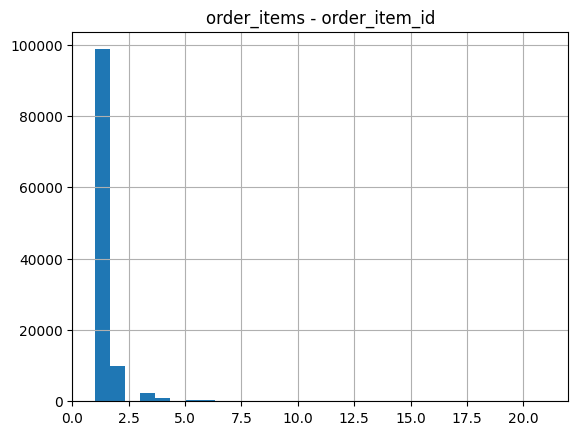

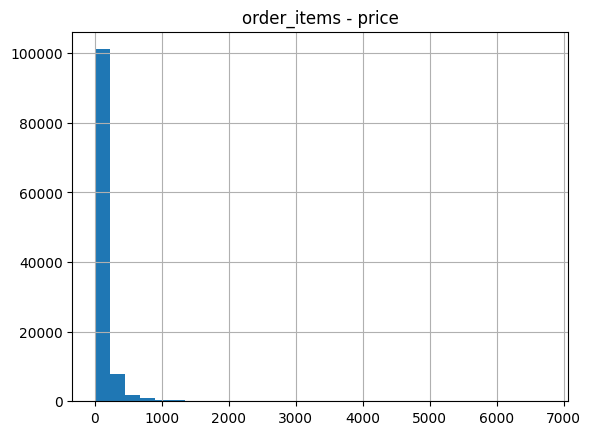

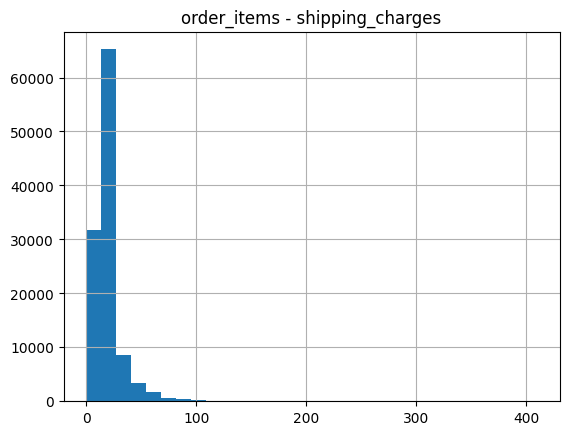

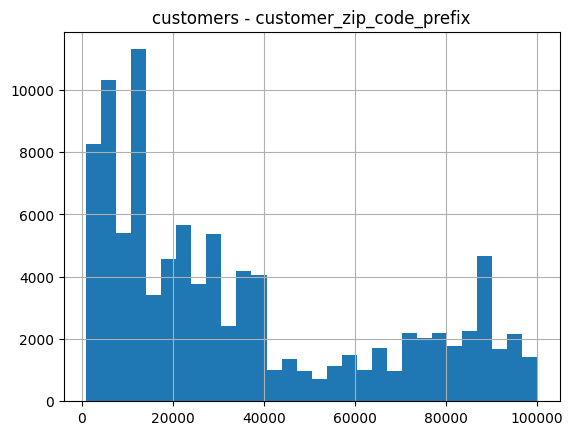

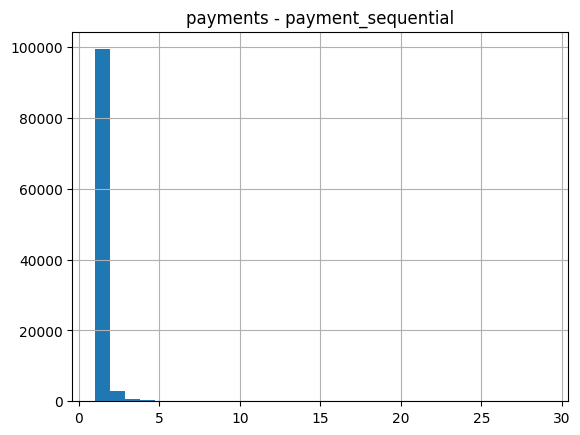

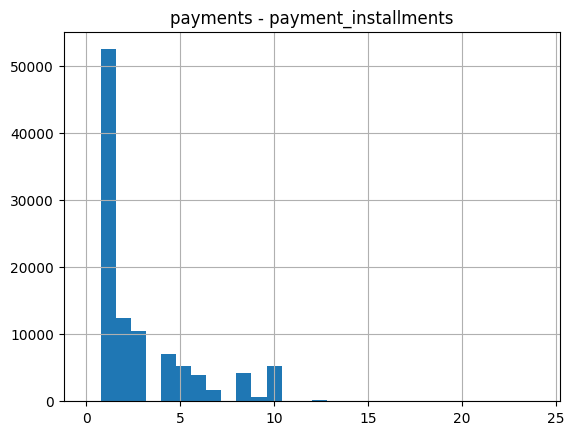

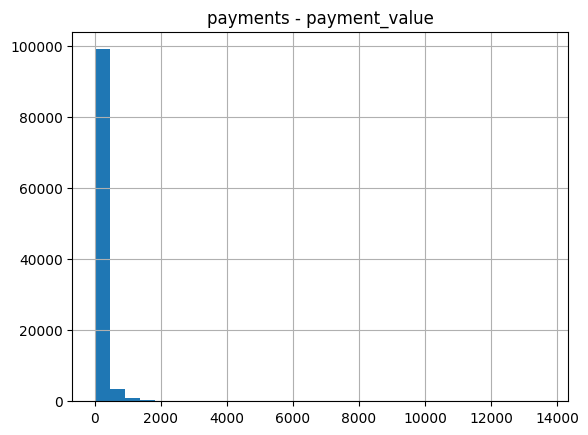

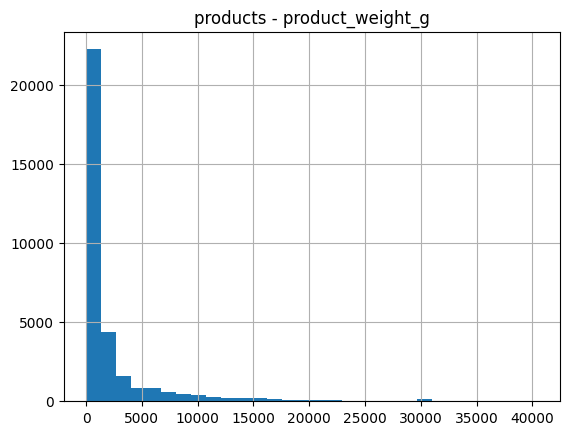

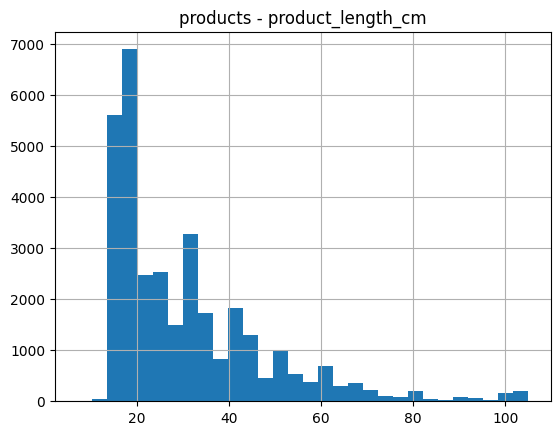

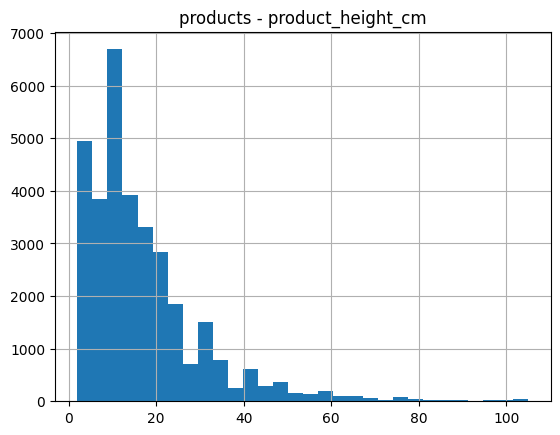

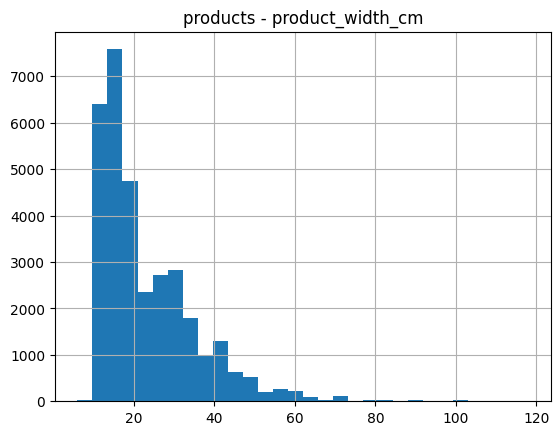

In [32]:
# STEP 6: DISTRIBUTION ANALYSIS
import matplotlib.pyplot as plt

for name, df in dfs.items():
    num_cols = df.select_dtypes(include='number').columns
    for col in num_cols:
        df[col].hist(bins=30)
        plt.title(f"{name} - {col}")
        plt.show()


In [33]:
# STEP 7: CATEGORICAL ANALYSIS

for name, df in dfs.items():
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        print(f"\n{name.upper()} - {col}")
        print(df[col].value_counts().head())



ORDERS - order_id
order_id
66dea50a8b16d9b4dee7af250b4be1a5    1
6ec4642f9993cc34f826cfb9068e5a2f    1
38e9133ce29f6bbe35aed9c3863dce01    1
dfc6eb45a2753ed9e6c6ef4987b44503    1
6f46d42016226f77893ed3978d6903d0    1
Name: count, dtype: int64

ORDERS - customer_id
customer_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
Name: count, dtype: int64

ORDERS - order_status
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
Name: count, dtype: int64

ORDER_ITEMS - order_id
order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
Name: count, dtype: int64

ORDER_ITEMS - product_id
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a

In [34]:
# STEP 8: RELATIONSHIP ANALYSIS (MERGED VIEW)
merged = (
    orders
    .merge(items, on='order_id', how='left')
    .merge(payments, on='order_id', how='left')
)


In [35]:
merged[['price', 'shipping_charges', 'payment_value']].corr()

,price,shipping_charges,payment_value
price,1.000000,0.415813,0.739501
shipping_charges,0.415813,1.000000,0.373891
payment_value,0.739501,0.373891,1.000000


In [36]:
# STEP 10: DATA QUALITY CHECKS

items[items['price'] <= 0]
payments[payments['payment_value'] <= 0]


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [37]:
# STEP 12: OUTLIER TREATMENT (OPTIONAL)

items['price_log'] = np.log1p(items['price'])


In [39]:
df.to_excel("cleaned_dataset.xlsx", index=False)

from google.colab import files
files.download("cleaned_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# Remove duplicates
orders = orders.drop_duplicates()
items = items.drop_duplicates()
customers = customers.drop_duplicates()
payments = payments.drop_duplicates()

# Handle missing values (example)
orders = orders.dropna()
items = items.dropna()
customers = customers.dropna()
payments = payments.dropna()

In [41]:
!pip install openpyxl

with pd.ExcelWriter("cleaned_retail_dataset.xlsx", engine='openpyxl') as writer:
    orders.to_excel(writer, sheet_name='orders_cleaned', index=False)
    items.to_excel(writer, sheet_name='items_cleaned', index=False)
    customers.to_excel(writer, sheet_name='customers_cleaned', index=False)
    payments.to_excel(writer, sheet_name='payments_cleaned', index=False)

from google.colab import files
files.download("cleaned_retail_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
orders.to_excel("orders_cleaned.xlsx", index=False)
items.to_excel("items_cleaned.xlsx", index=False)
customers.to_excel("customers_cleaned.xlsx", index=False)
payments.to_excel("payments_cleaned.xlsx", index=False)

from google.colab import files
files.download("orders_cleaned.xlsx")
files.download("items_cleaned.xlsx")
files.download("customers_cleaned.xlsx")
files.download("payments_cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
order_items_cleaned = items.drop_duplicates()

In [45]:
order_items_cleaned.to_excel("order_items_cleaned.xlsx", index=False)

from google.colab import files
files.download("order_items_cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>